In [1]:
import os
import warnings
import boto3
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, roc_curve, brier_score_loss
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from scipy.stats import ks_2samp

#### Functions

In [2]:
# compute metrics for a model
def compute_model_metrics(arr_y_true, arr_y_pred, str_model_name):
    flt_auc = roc_auc_score(arr_y_true, arr_y_pred)
    flt_gini = 2 * flt_auc - 1
    flt_ks = ks_2samp(arr_y_pred[arr_y_true == 1], arr_y_pred[arr_y_true == 0]).statistic
    flt_brier = brier_score_loss(arr_y_true, arr_y_pred)
    flt_median = np.median(arr_y_pred)
    return {
        'str_model': str_model_name,
        'flt_auc': flt_auc,
        'flt_gini': flt_gini,
        'flt_ks': flt_ks,
        'flt_brier': flt_brier,
        'flt_median_pred': flt_median,
    }

In [3]:
# plot roc comparison
def plot_roc_comparison(arr_y_true, dict_models, str_filename='output/roc_comparison.png'):
    fig, ax = plt.subplots(figsize=(8, 6))
    list_colors = ['steelblue', 'salmon', 'seagreen', 'orange']
    for (str_name, arr_y_pred), str_color in zip(dict_models.items(), list_colors):
        flt_auc = roc_auc_score(arr_y_true, arr_y_pred)
        arr_fpr, arr_tpr, _ = roc_curve(arr_y_true, arr_y_pred)
        ax.plot(arr_fpr, arr_tpr, color=str_color, linewidth=2, label=f'{str_name} (AUC={flt_auc:.4f})')
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1)
    ax.set_title('ROC Comparison: Champion vs Challenger', fontsize=16)
    ax.set_xlabel('False Positive Rate', fontsize=12)
    ax.set_ylabel('True Positive Rate', fontsize=12)
    ax.legend(loc='lower right')
    plt.tight_layout()
    plt.savefig(str_filename, dpi=300)
    plt.show()

In [4]:
# plot kde comparison
def plot_kde_comparison(dict_models, str_filename='output/kde_comparison.png'):
    warnings.filterwarnings('ignore')
    fig, ax = plt.subplots(figsize=(10, 5))
    list_colors = ['steelblue', 'salmon', 'seagreen', 'orange']
    for (str_name, arr_y_pred), str_color in zip(dict_models.items(), list_colors):
        flt_median = np.median(arr_y_pred)
        sns.kdeplot(arr_y_pred, ax=ax, color=str_color, linewidth=2, label=f'{str_name} (Median={flt_median:.4f})', fill=True, alpha=0.2)
    ax.set_title('KDE Comparison: Champion vs Challenger', fontsize=16)
    ax.set_xlabel('Predicted Probability', fontsize=12)
    ax.set_ylabel('Density', fontsize=12)
    ax.legend(loc='lower right')
    plt.tight_layout()
    plt.savefig(str_filename, dpi=300)
    plt.show()
    warnings.filterwarnings('default')

In [5]:
# plot calibration comparison
def plot_calibration_comparison(arr_y_true, dict_models, int_n_bins=10, str_filename='output/calibration_comparison.png'):
    fig, ax = plt.subplots(figsize=(8, 6))
    list_colors = ['steelblue', 'salmon', 'seagreen', 'orange']
    for (str_name, arr_y_pred), str_color in zip(dict_models.items(), list_colors):
        flt_brier = brier_score_loss(arr_y_true, arr_y_pred)
        arr_bins = np.linspace(0, 1, int_n_bins + 1)
        arr_bin_indices = np.digitize(arr_y_pred, arr_bins) - 1
        arr_bin_indices = np.clip(arr_bin_indices, 0, int_n_bins - 1)
        list_predicted = []
        list_actual = []
        for i in range(int_n_bins):
            arr_mask = arr_bin_indices == i
            if arr_mask.sum() > 0:
                list_predicted.append(arr_y_pred[arr_mask].mean())
                list_actual.append(arr_y_true[arr_mask].mean())
        ax.plot(list_predicted, list_actual, marker='o', color=str_color, linewidth=2, label=f'{str_name} (Brier={flt_brier:.4f})')
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1)
    ax.set_title('Calibration Comparison: Champion vs Challenger', fontsize=16)
    ax.set_xlabel('Mean Predicted Probability', fontsize=12)
    ax.set_ylabel('Actual Default Rate', fontsize=12)
    ax.legend(loc='lower right')
    plt.tight_layout()
    plt.savefig(str_filename, dpi=300)
    plt.show()

In [6]:
# plot metric comparison bar chart
def plot_metric_comparison(df_metrics, str_metric, str_title, str_filename):
    fig, ax = plt.subplots(figsize=(8, 5))
    list_colors = ['steelblue', 'salmon', 'seagreen', 'orange']
    ax.bar(range(len(df_metrics)), df_metrics[str_metric], color=list_colors[:len(df_metrics)], edgecolor='black')
    ax.set_xticks(range(len(df_metrics)))
    ax.set_xticklabels(df_metrics['str_model'], rotation=0)
    ax.set_title(str_title, fontsize=16)
    ax.set_ylabel(str_metric, fontsize=12)
    # annotate bars
    for i, flt_val in enumerate(df_metrics[str_metric]):
        ax.text(i, flt_val + (ax.get_ylim()[1] * 0.01), f'{flt_val:.4f}', ha='center', fontsize=11)
    ax.set_ylim(top=ax.get_ylim()[1] * 1.15)
    plt.tight_layout()
    plt.savefig(str_filename, dpi=300)
    plt.show()

#### Constants

In [7]:
# bucket
str_bucket = os.getcwd().split('/')[4].replace('_', '-')
print(f'Bucket: {str_bucket}')

# step
str_step = os.getcwd().split('/')[-1]
print(f'Step: {str_step}')

# s3 input path
str_s3_input = f's3://{str_bucket}/03_preprocessing'
print(f'S3 Input: {str_s3_input}')

# target
str_target = 'default_12m'
print(f'Target: {str_target}')

# champion model (current production model)
str_champion_model_path = '../04_model/output/xgboost_model.joblib'
str_champion_feature_cols_path = '../04_model/output/feature_cols.joblib'

# output directory
os.makedirs('output', exist_ok=True)

Bucket: credit-risk-claude
Step: 08_champion_challenger
S3 Input: s3://credit-risk-claude/03_preprocessing
Target: default_12m


#### Read Data and Models

In [8]:
# read train, valid, and test data
df_train = pd.read_parquet(f'{str_s3_input}/df_train_clean.parquet')
df_valid = pd.read_parquet(f'{str_s3_input}/df_valid_clean.parquet')
df_test = pd.read_parquet(f'{str_s3_input}/df_test_clean.parquet')
df_train_valid = pd.concat([df_train, df_valid], ignore_index=True)
print(f'Train+Valid: {df_train_valid.shape}')
print(f'Test: {df_test.shape}')

# load champion model and feature columns
model_champion = joblib.load(str_champion_model_path)
list_feature_cols = joblib.load(str_champion_feature_cols_path)
print(f'Champion features: {len(list_feature_cols)}')

Train+Valid: (21511, 20)
Test: (3797, 20)
Champion features: 12


/home/ec2-user/anaconda3/envs/tensorflow2_p310/lib/python3.12/site-packages/xgboost/core.py:265: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc 2.28+) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(


#### Train Challenger Model

The challenger is a logistic regression with StandardScaler, tuned via GridSearchCV over regularization strength (C) and penalty type (L1/L2). Logistic regression is the regulatory baseline in credit risk and provides an interpretability benchmark against the tuned XGBoost champion. Trained on the same combined train+valid data as the champion for a fair comparison.

In [9]:
# train challenger logistic regression with grid search
warnings.filterwarnings('ignore')
pipeline_lr = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=1000, random_state=42)),
])

dict_param_grid = {
    'lr__C': [0.001, 0.01, 0.1, 1.0, 10.0],
    'lr__penalty': ['l1', 'l2'],
    'lr__solver': ['saga'],
}

grid_search = GridSearchCV(pipeline_lr, dict_param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
grid_search.fit(df_train_valid[list_feature_cols].values, df_train_valid[str_target].values)
model_challenger = grid_search.best_estimator_
warnings.filterwarnings('default')
print(f'Challenger LR trained. Best params: {grid_search.best_params_}')

Challenger LR trained. Best params: {'lr__C': 0.01, 'lr__penalty': 'l1', 'lr__solver': 'saga'}


#### Generate Predictions

Both models are scored on the same test set to ensure a fair comparison. The test set is the out-of-time holdout that neither model has seen during training or validation.

In [10]:
# generate predictions
arr_y_test = df_test[str_target].values

arr_pred_champion = model_champion.predict_proba(df_test[list_feature_cols].values)[:, 1]
arr_pred_challenger = model_challenger.predict_proba(df_test[list_feature_cols].values)[:, 1]

# dict for plot functions
dict_models = {
    'Champion (XGBoost)': arr_pred_champion,
    'Challenger (Logistic Regression)': arr_pred_challenger,
}

#### Metrics Comparison

Side-by-side comparison of all key metrics. The challenger model should demonstrate improvement in discrimination (AUC, Gini, KS) and/or calibration (Brier) without degrading other metrics.

In [11]:
# compute metrics for both models
list_rows = [
    compute_model_metrics(arr_y_test, arr_pred_champion, 'Champion (XGBoost)'),
    compute_model_metrics(arr_y_test, arr_pred_challenger, 'Challenger (Logistic Regression)'),
]
df_metrics = pd.DataFrame(list_rows)
df_metrics.to_csv('output/champion_challenger_metrics.csv', index=False)
df_metrics

,str_model,flt_auc,flt_gini,flt_ks,flt_brier,flt_median_pred
0,Champion (XGBoost),0.803229,0.606458,0.477883,0.119567,0.130033
1,Challenger (Logistic Regression),0.794250,0.588500,0.466587,0.122831,0.141567


#### AUC Comparison

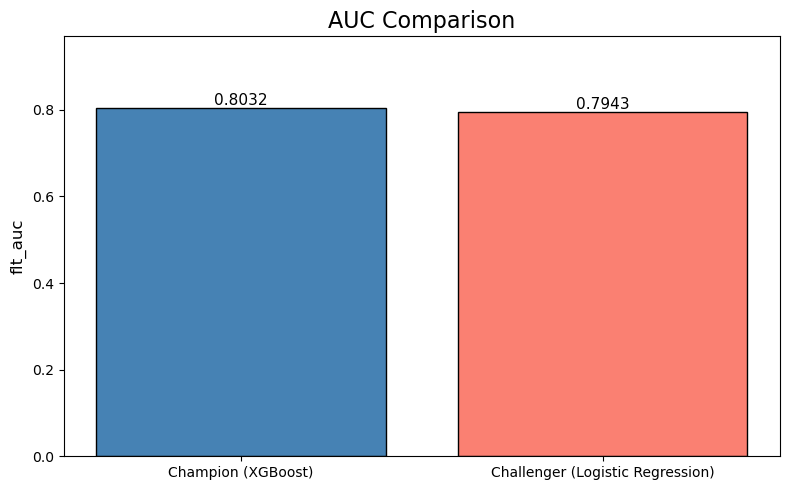

In [12]:
plot_metric_comparison(df_metrics, 'flt_auc', 'AUC Comparison', 'output/auc_comparison.png')

#### Gini Comparison

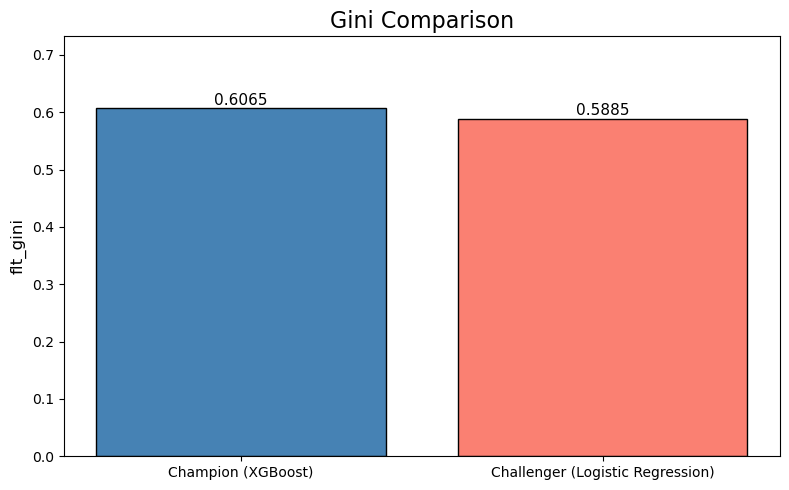

In [13]:
plot_metric_comparison(df_metrics, 'flt_gini', 'Gini Comparison', 'output/gini_comparison.png')

#### KS Comparison

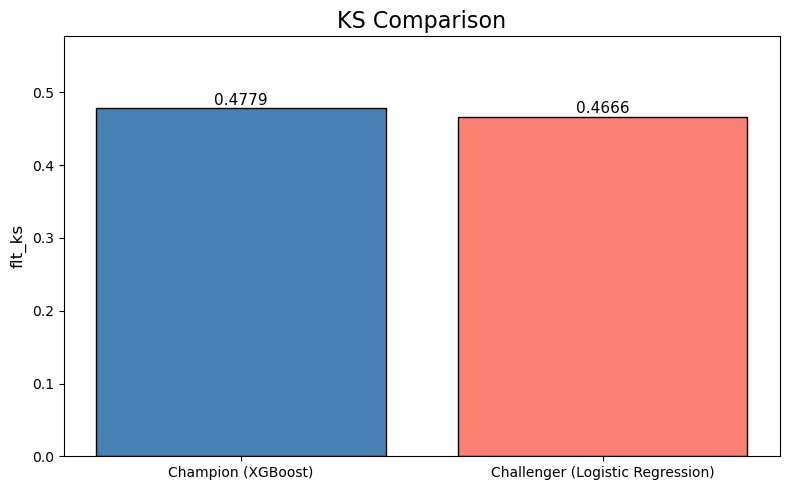

In [14]:
plot_metric_comparison(df_metrics, 'flt_ks', 'KS Comparison', 'output/ks_comparison.png')

#### ROC Comparison

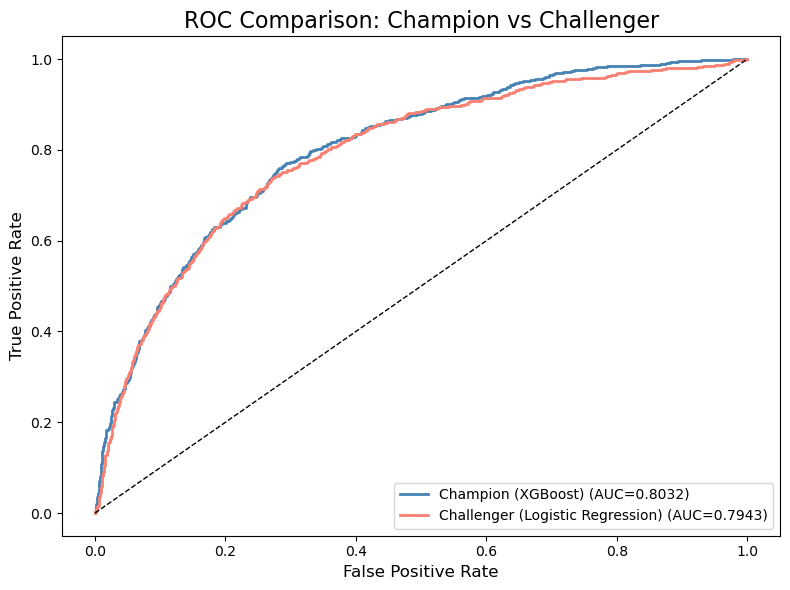

In [15]:
plot_roc_comparison(arr_y_test, dict_models)

#### Calibration Comparison

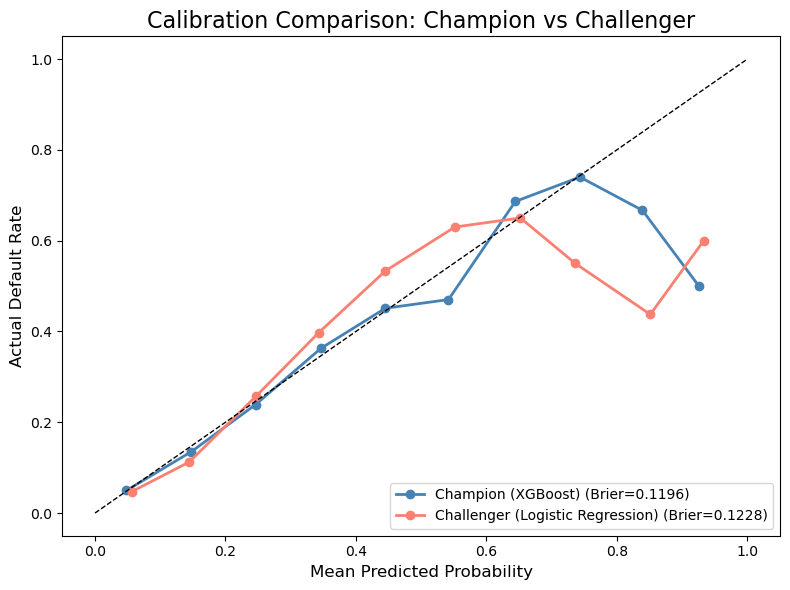

In [16]:
plot_calibration_comparison(arr_y_test, dict_models)

#### KDE Comparison

Comparing the distribution of predicted probabilities between champion and challenger. Significant differences in shape or location indicate the models are behaving differently.

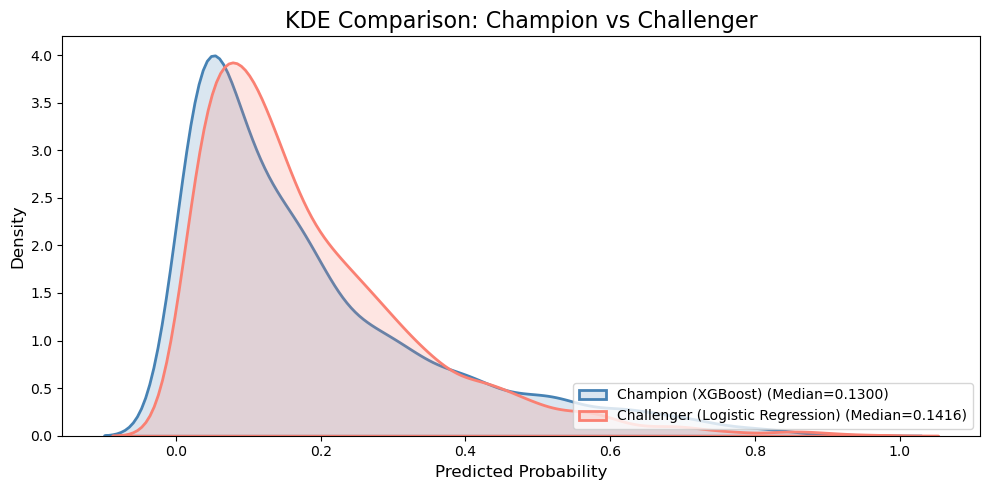

In [17]:
plot_kde_comparison(dict_models)

#### Recommendation

In [18]:
# automated recommendation based on metrics
dict_champion = df_metrics[df_metrics['str_model'] == 'Champion (XGBoost)'].iloc[0]
dict_challenger = df_metrics[df_metrics['str_model'] == 'Challenger (Logistic Regression)'].iloc[0]

print('=== Champion vs Challenger Summary ===')
print(f'AUC:   Champion={dict_champion["flt_auc"]:.4f}  Challenger={dict_challenger["flt_auc"]:.4f}  Delta={dict_challenger["flt_auc"] - dict_champion["flt_auc"]:+.4f}')
print(f'Gini:  Champion={dict_champion["flt_gini"]:.4f}  Challenger={dict_challenger["flt_gini"]:.4f}  Delta={dict_challenger["flt_gini"] - dict_champion["flt_gini"]:+.4f}')
print(f'KS:    Champion={dict_champion["flt_ks"]:.4f}  Challenger={dict_challenger["flt_ks"]:.4f}  Delta={dict_challenger["flt_ks"] - dict_champion["flt_ks"]:+.4f}')
print(f'Brier: Champion={dict_champion["flt_brier"]:.4f}  Challenger={dict_challenger["flt_brier"]:.4f}  Delta={dict_challenger["flt_brier"] - dict_champion["flt_brier"]:+.4f}')
print()

# recommendation logic
bool_better_auc = dict_challenger['flt_auc'] > dict_champion['flt_auc']
bool_better_brier = dict_challenger['flt_brier'] < dict_champion['flt_brier']

if bool_better_auc and bool_better_brier:
    print('RECOMMENDATION: Challenger improves both discrimination and calibration. Recommend promoting to production.')
elif bool_better_auc:
    print('RECOMMENDATION: Challenger improves discrimination but not calibration. Review calibration impact before promoting.')
elif bool_better_brier:
    print('RECOMMENDATION: Challenger improves calibration but not discrimination. Consider promoting if calibration is the priority.')
else:
    print('RECOMMENDATION: Challenger does not improve over champion. Retain current production model.')

=== Champion vs Challenger Summary ===
AUC:   Champion=0.8032  Challenger=0.7943  Delta=-0.0090
Gini:  Champion=0.6065  Challenger=0.5885  Delta=-0.0180
KS:    Champion=0.4779  Challenger=0.4666  Delta=-0.0113
Brier: Champion=0.1196  Challenger=0.1228  Delta=+0.0033

RECOMMENDATION: Challenger does not improve over champion. Retain current production model.
